In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ggplot import mtcars

mtcars.index = mtcars["name"]
mtcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
name,,,,,,,,,,,,
Mazda RX4,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
# mean of each of the columns
mtcars.mean()

mpg      20.090625
cyl       6.187500
disp    230.721875
hp      146.687500
drat      3.596563
wt        3.217250
qsec     17.848750
vs        0.437500
am        0.406250
gear      3.687500
carb      2.812500
dtype: float64

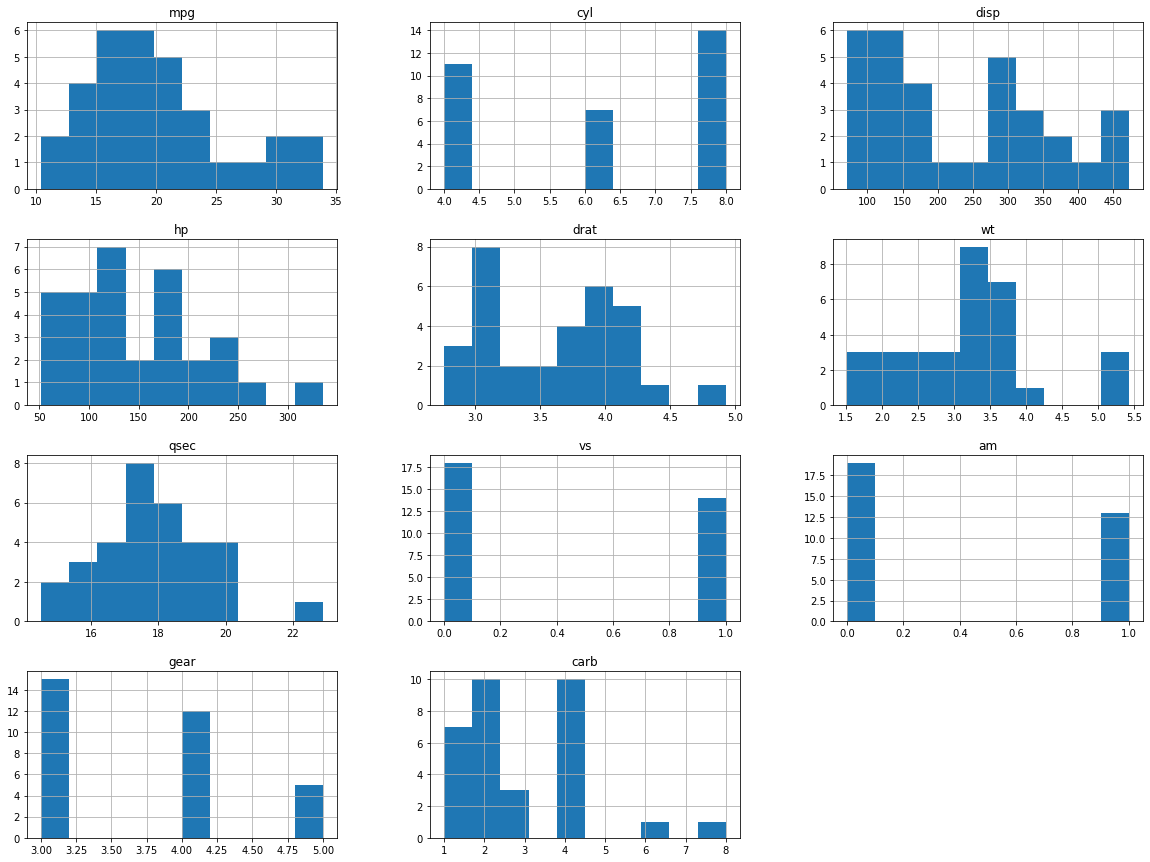

In [4]:
# mean of each row 
mtcarsMeanCarWise = mtcars.mean(axis=1)

# median of each column
medianCarsFeatures = mtcars.median(axis=0)

mtcars.hist(bins = 10, figsize = (20,15))
# bins - Divides data into 10 equal intervals
# figsize - makes the figure large enough so all plots are visible clearly

plt.show()



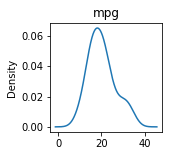

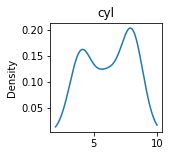

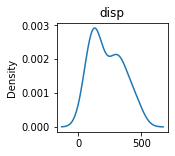

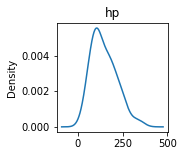

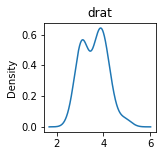

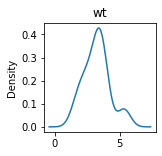

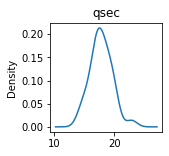

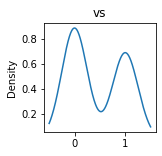

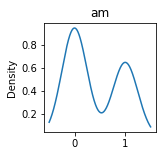

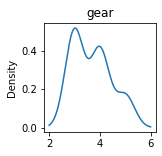

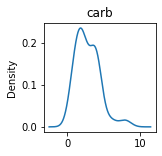

In [5]:
# density curve - Shows how data is distributed, Area under the curve = 1, Peaks → where values are concentrated
# Smooth → no bins like histograms

for col in mtcars.columns:
    if col != "name":
        mtcars[col].plot(kind="density", figsize=(2,2), title=col)
        plt.show()

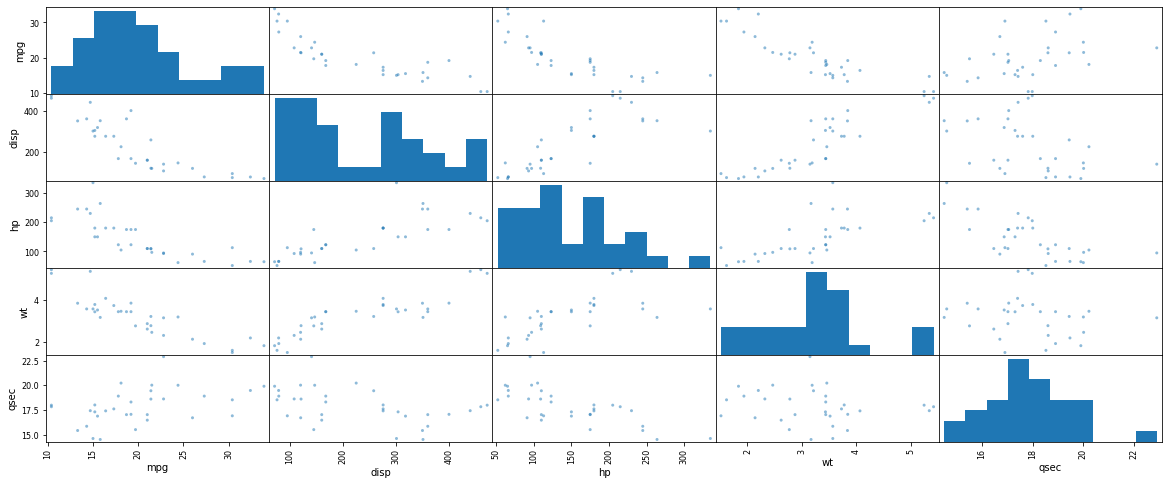

In [2]:
# Plot the correlation for the following attributes: mpg, disp, hp, wt, qsec. 
from pandas.plotting import scatter_matrix

cols = ["mpg", "disp", "hp", "wt", "qsec"]
scatter_matrix(mtcars[cols], figsize=(20,8),diagonal="hist")
#
plt.show()

 #### skewness 
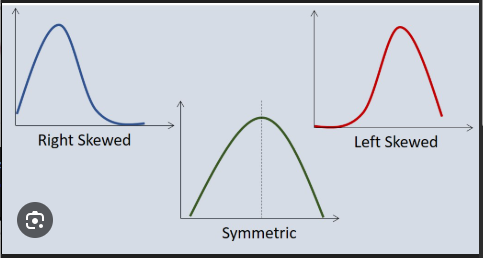
We use skewness as a measure of symmetry. If the skewness of is zero then the distribution represented is perfectly symmetric. If the skewness is negative, then the distribution is skewed to the left, while if the skew is positive then the distribution is skewed to the right. Hence, it can also be considered as a measure of normality since normal distributions are symmetric and hence have a zero skew. 

In [8]:
mtcars.skew()
#for coumn in mtcars.columns:
    

mpg     0.672377
cyl    -0.192261
disp    0.420233
hp      0.799407
drat    0.292780
wt      0.465916
qsec    0.406347
vs      0.264542
am      0.400809
gear    0.582309
carb    1.157091
dtype: float64

In [9]:
mtcars["mpg"].describe()

count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

In [13]:
# Inter-Quantile spread (spread of data (IQR) = Q3 − Q1, where Q3 is 75th percentile and Q1 is 25th percentile
# This measures: Middle 50% spread of data & Robust against outliers
# Quantile calculations require numeric data
# Why IQR is important
#     ✔ Measures data spread
#     ✔ Not affected by extreme values
#     ✔ Used in box plots
#     ✔ Helps detect outliers

IQR_mpg = mtcars["mpg"].quantile(0.75) - mtcars["mpg"].quantile(0.25)
print(IQR_mpg)

7.375


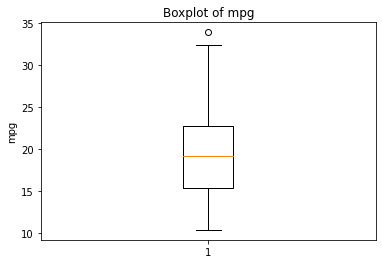

In [3]:
# Box Plot
# Middle line inside the box → median mpg (≈ 19.2)
# Box → interquartile range (Q1 to Q3), where the middle 50% of cars lie
# Whiskers → typical minimum and maximum values
# Dot above → an outlier (very high mpg cars like ~33–34 mpg)

plt.boxplot(mtcars["mpg"])   #  <library: Matplotlib & best for:Full customization>
plt.ylabel("mpg")            #  <library: Pandas & best for: Multiple columns>
plt.title("Boxplot of mpg")  #  <library: Pandas & best for: Quick & clean>
plt.show()

<AxesSubplot:>

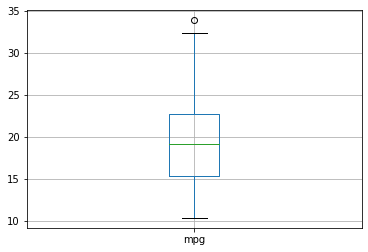

In [4]:
pd.DataFrame(mtcars["mpg"]).boxplot()

<AxesSubplot:>

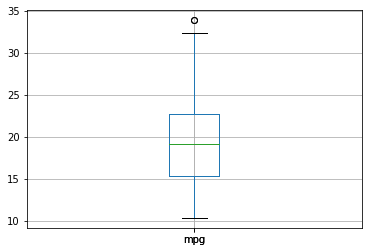

In [16]:
#
mtcars["mpg"].plot.box()


In [25]:
mtcars["mpg"].mean()
mtcars["mpg"].std()
mtcars["mpg"].var()

36.32410282258065

In [29]:
# Extract cars with automatic transmission and cars with manual transmission into separate variables

mtCarsAutomatic = [mtcars["am"]==0]
mtCarsManual = [mtcars["am"]==1]
print(mtCarsAutomatic)


[name
Mazda RX4              False
Mazda RX4 Wag          False
Datsun 710             False
Hornet 4 Drive          True
Hornet Sportabout       True
Valiant                 True
Duster 360              True
Merc 240D               True
Merc 230                True
Merc 280                True
Merc 280C               True
Merc 450SE              True
Merc 450SL              True
Merc 450SLC             True
Cadillac Fleetwood      True
Lincoln Continental     True
Chrysler Imperial       True
Fiat 128               False
Honda Civic            False
Toyota Corolla         False
Toyota Corona           True
Dodge Challenger        True
AMC Javelin             True
Camaro Z28              True
Pontiac Firebird        True
Fiat X1-9              False
Porsche 914-2          False
Lotus Europa           False
Ford Pantera L         False
Ferrari Dino           False
Maserati Bora          False
Volvo 142E             False
Name: am, dtype: bool]


In [30]:
print(mtCarsManual)

[name
Mazda RX4               True
Mazda RX4 Wag           True
Datsun 710              True
Hornet 4 Drive         False
Hornet Sportabout      False
Valiant                False
Duster 360             False
Merc 240D              False
Merc 230               False
Merc 280               False
Merc 280C              False
Merc 450SE             False
Merc 450SL             False
Merc 450SLC            False
Cadillac Fleetwood     False
Lincoln Continental    False
Chrysler Imperial      False
Fiat 128                True
Honda Civic             True
Toyota Corolla          True
Toyota Corona          False
Dodge Challenger       False
AMC Javelin            False
Camaro Z28             False
Pontiac Firebird       False
Fiat X1-9               True
Porsche 914-2           True
Lotus Europa            True
Ford Pantera L          True
Ferrari Dino            True
Maserati Bora           True
Volvo 142E              True
Name: am, dtype: bool]


{'whiskers': [<matplotlib.lines.Line2D at 0x7fcee8140518>,
 'caps': [<matplotlib.lines.Line2D at 0x7fcee8140ac8>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fcee81402b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fcee814b0b8>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fcee814b390>],
 'means': []}

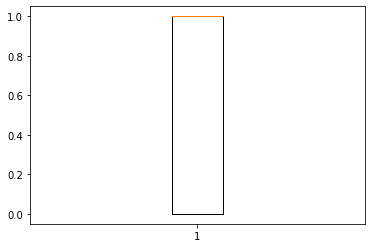

In [31]:
plt.boxplot(mtCarsAutomatic)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fcee8105da0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fcee8091390>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fcee8105b38>],
 'medians': [<matplotlib.lines.Line2D at 0x7fcee8091940>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fcee8091c18>],
 'means': []}

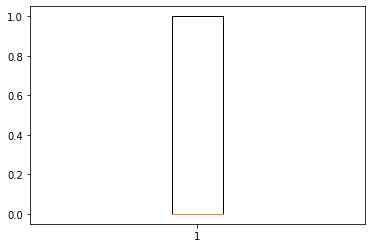

In [32]:
plt.boxplot(mtCarsManual)

<AxesSubplot:title={'center':'mpg'}, xlabel='[am]'>

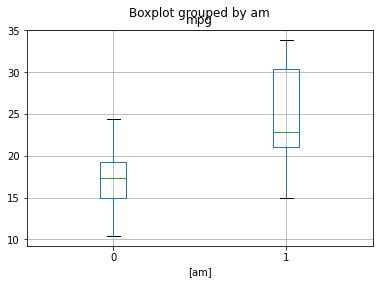

In [19]:
pd.DataFrame(mtcars[["mpg", "am"]]).boxplot(by="am")

# What each part means
# mtcars[["mpg", "am"]] → Selects only miles per gallon and transmission
# pd.DataFrame(...) → Ensures the data is a DataFrame (already is, but harmless)
# .boxplot(by="am") → Groups the data by am and draws separate box plots

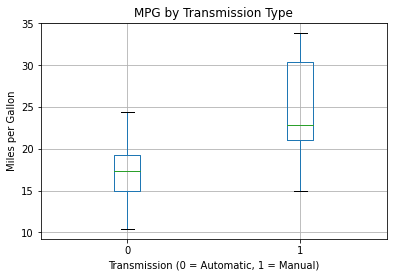

In [5]:
mtcars[["mpg", "am"]].boxplot(by="am")
plt.xlabel("Transmission (0 = Automatic, 1 = Manual)")
plt.ylabel("Miles per Gallon")
plt.title("MPG by Transmission Type")
plt.suptitle("")   # removes extra pandas title
plt.show()

In [24]:
mtcars["wt"].mean()

3.2172499999999995

In [7]:
mtcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
name,,,,,,,,,,,,
Mazda RX4,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [25]:
# What is the mean value of all the features for the car Toyota Corolla?

mtcars.mean(axis=1) # row-wise mean

name
Mazda RX4              29.907273
Mazda RX4 Wag          29.981364
Datsun 710             23.598182
Hornet 4 Drive         38.739545
Hornet Sportabout      53.664545
Valiant                35.049091
Duster 360             59.720000
Merc 240D              24.634545
Merc 230               27.233636
Merc 280               31.860000
Merc 280C              31.787273
Merc 450SE             46.430909
Merc 450SL             46.500000
Merc 450SLC            46.350000
Cadillac Fleetwood     66.232727
Lincoln Continental    66.058545
Chrysler Imperial      65.972273
Fiat 128               19.440909
Honda Civic            17.742273
Toyota Corolla         18.814091
Toyota Corona          24.888636
Dodge Challenger       47.240909
AMC Javelin            46.007727
Camaro Z28             58.752727
Pontiac Firebird       57.379545
Fiat X1-9              18.928636
Porsche 914-2          24.779091
Lotus Europa           24.880273
Ford Pantera L         60.971818
Ferrari Dino           34.508182
Maser

In [29]:

mtcars["hp"].skew()


0.7994066925956381

In [28]:
mtcars["wt"].median()

3.325

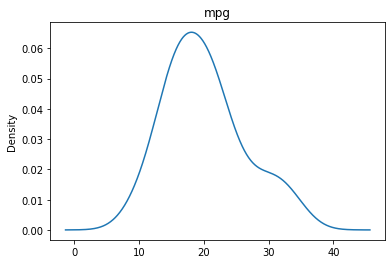

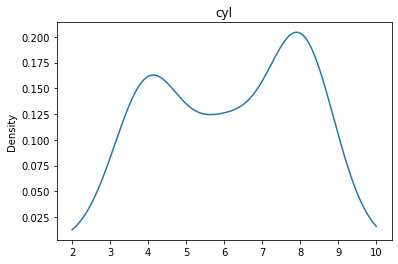

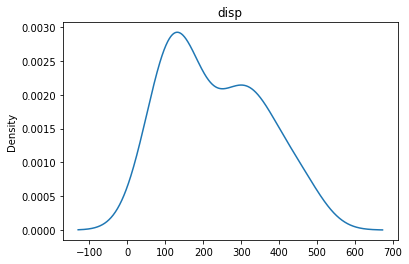

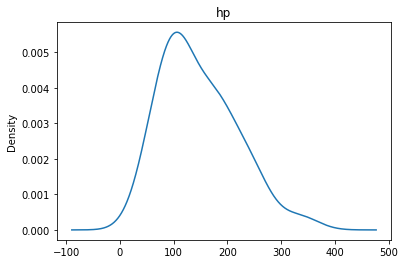

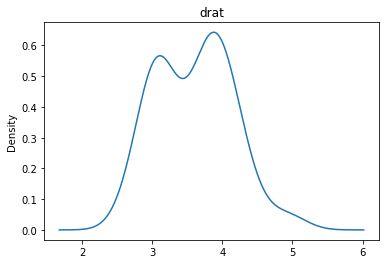

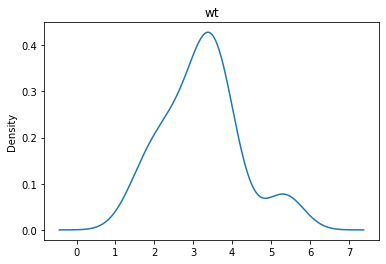

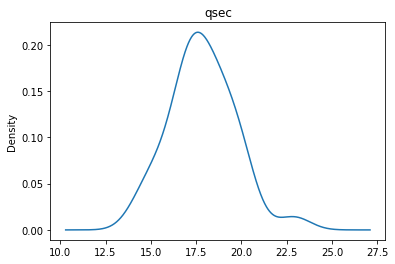

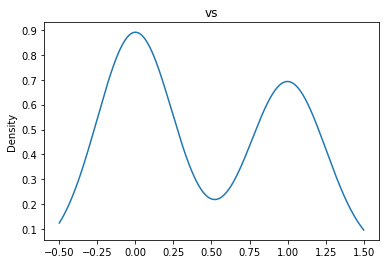

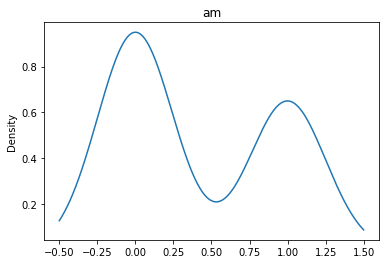

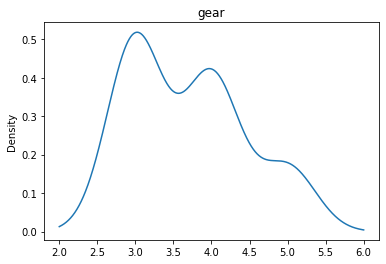

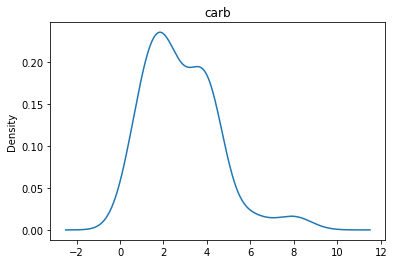

In [31]:
# Which of these are unimodal? - qsec, vs, drat
# Unimodel means a dataset or distribution that has one single peak (one mode).
# Examples of unimodel: A bell-shaped normal distribution, Exam scores where most students scored around 70
# bimodels are also exist - am

for col in mtcars.columns:
    if col != "name":
        mtcars[col].plot(kind="density")
        plt.title(col)
        plt.show()

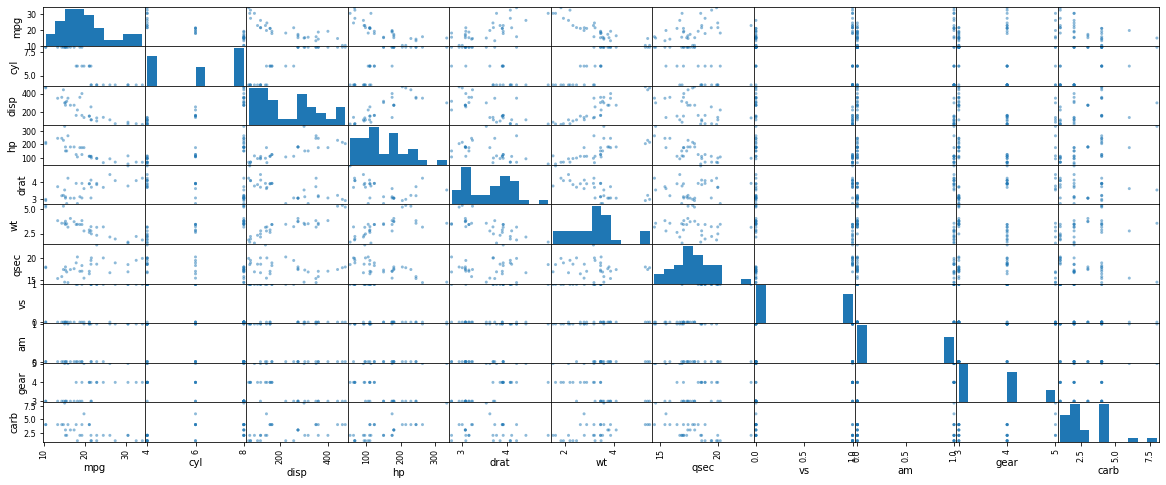

In [41]:
# Which of these are most strongly positively correlated? - mpg and disp, mpg and hp, wt and disp & hp and qsec

from pandas.plotting import scatter_matrix

cols = ['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am',
       'gear', 'carb']
scatter_matrix(mtcars[cols], figsize=(20,8))
plt.show()

# or

mtcars.corr() # ranges from -1 to 1. 


In [43]:
# Which of these is most skewed to the right?
# higher +ve skew -> right skewed
# higher -ve skew -> left skewed
mtcars.skew()

mpg     0.672377
cyl    -0.192261
disp    0.420233
hp      0.799407
drat    0.292780
wt      0.465916
qsec    0.406347
vs      0.264542
am      0.400809
gear    0.582309
carb    1.157091
dtype: float64

In [46]:
# What is the IQR (Interquartile Range) of 'mpg' column?
IQR = mtcars["mpg"].quantile(0.75) - mtcars["mpg"].quantile(0.25)
print(IQR)

7.375


In [47]:
mean_mpg = mtcars["mpg"].mean()
std_mpg = mtcars["mpg"].std()
var_mpg = mtcars["mpg"].var()
print(mean_mpg)
print(std_mpg)
print(var_mpg)

20.090624999999996
6.026948052089105
36.32410282258065


In [ ]:
# Normal (Gaussian) Distribution

# Draws samples from a normal (Gaussian) distribution
# Mean (μ) = 0 & Standard deviation (σ) = 1
# Values range from −∞ to +∞ (most are near 0)
# Distribution is bell-shaped => 68% of values lie between −1 and +1 & 95% between −2 and +2
# Example: x = np.random.normal(size=100000)
# Typical uses: Noise modeling, Statistical simulations, Machine learning (weight initialization, error terms)


# Uniform Distribution

# Draws samples from a uniform distribution
# Range is [0, 1)
# All values are between 0 and 1. Every value in that range is equally likely
# Flat (not bell-shaped)
# Example: y = np.random.rand(10000)
# Typical uses: Random sampling, Probabilities, Generating random coordinates or masks
          
# Side-by-side comparison
#Feature        	np.random.normal()  	np.random.rand()
#Distribution   	Normal (Gaussian)   	Uniform
#Shape          	Bell curve          	Flat
#Range          	(−∞, +∞)            	[0, 1)
#Mean           	0                   	~0.5
#Std Dev        	1                   	~0.288
#Negative values	Yes                 	No

# Normal distribution → “Most things are average, extremes are rare” 
# Use normal when data should cluster around a mean with natural variation

# Uniform distribution → “Every value has the same chance” 
# Use rand when all values in a range should be equally likely

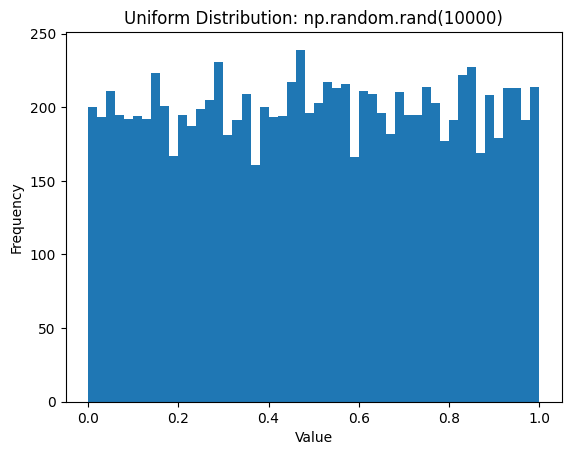

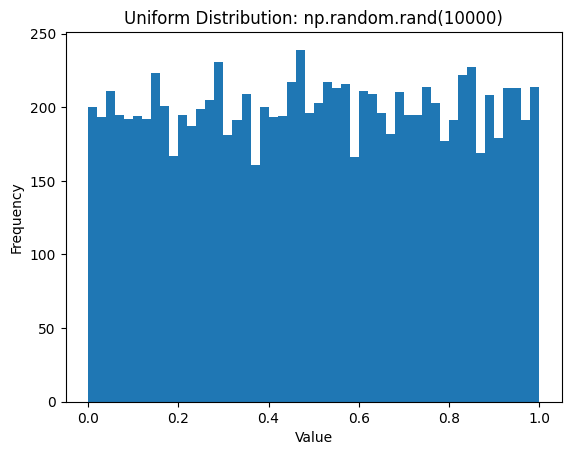

<AxesSubplot:ylabel='Density'>

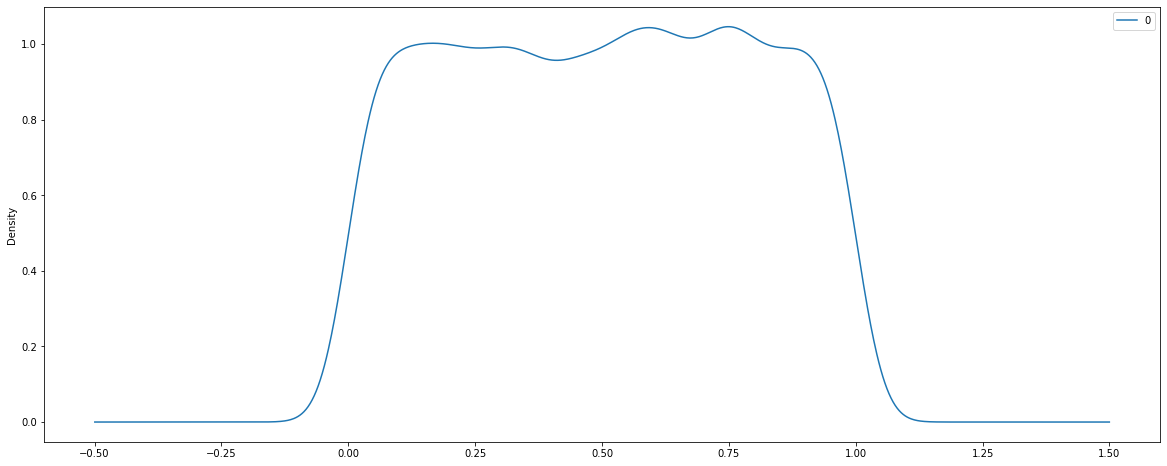

In [5]:
import numpy as np
import pandas as pd

numbers = np.random.rand(10000)
mean = numbers.mean()
med= numbers.median()
pd.DataFrame(numbers).plot(kind="density", figsize=(20,8))
#plt.show()

In [8]:
print(numbers)
mean = pd.DataFrame(numbers).mean()
med= pd.DataFrame(numbers).median()
print(mean)
print(med)

[0.14896008 0.81588724 0.8435384  ... 0.01140219 0.80691422 0.6338968 ]
0    0.501827
dtype: float64
0    0.507936
dtype: float64


Mean value: 0.00015526736652919936
Median value: 0.0020560797422859924


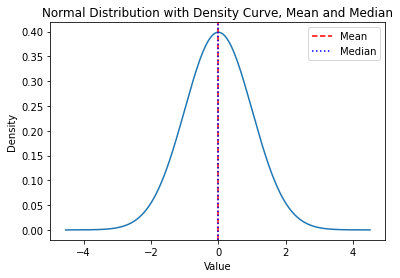

In [23]:
# Generate 10000 random normally distributed numbers and plot the density curve along with the median and mean.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm # probability density function (PDF) of normal distribution

norm_data = np.random.normal(size=100000)
mean_val = np.mean(norm_data)
median_val = np.median(norm_data)
print(f'Mean value: {mean_val}')
print(f'Median value: {median_val}')

# pd.DataFrame(norm_data).plot(kind="density", figsize=(20,8)) # What this would do (if uncommented) ->
# Converts NumPy array → Pandas DataFrame, Plots kernel density estimate (KDE) & Automatically smooths the curve
# Why commented? - instead plotting theoretical density using SciPy (more precise)

x = np.linspace(norm_data.min(), norm_data.max(), 500) 
# Generates 500 evenly spaced values from minimum to maximum of your data. These x-values are needed to plot a smooth curve
# np.linspace() is a NumPy function used to generate evenly spaced numbers over a specified interval.
plt.plot(x, norm.pdf(x, mean_val, np.std(norm_data)))
# norm.pdf(<x-axis values>, <μ (mean)>, <σ (standard deviation)>) → Probability Density Function of a normal distribution.
# This draws the theoretical bell curve matching your data.
# Think of plotting a hill: linspace → lays the road, norm.pdf → gives the height of the hill at each point & 
# plt.plot(x, y) → draws the hill

# plt.axvline() draws a vertical reference line on a plot at a specified x-value.
plt.axvline(mean_val, linestyle='--', color='red', label='Mean')
plt.axvline(median_val, linestyle=':', color='blue', label='Median')
# If the two lines overlap → distribution is symmetric.

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Normal Distribution with Density Curve, Mean and Median")
plt.legend() # displays line labels

plt.show()

In [ ]:
# norm.pdf() comes from SciPy and represents the Probability Density Function (PDF) of a normal (Gaussian) distribution.
# <<      norm.pdf() gives the height of the normal curve at x, not probability        >>
# What PDF means (conceptually): 
# For a continuous variable: PDF does NOT give probability at a single point. It gives density (height of the curve) 
# at that point
# 👉 Probability is found by area under the curve, not height.
# Syntax: norm.pdf(x, loc, scale) 
              # where x	Value(s) where density is evaluated, loc	Mean (μ) & scale	Standard deviation (σ)
    
# Example: norm.pdf(0, loc=0, scale=1) => o/p: 0.3989 <This is the maximum height of the standard normal curve.>

# Vectorized usage (most common) <Used for plotting smooth curves>
# x = np.linspace(-4, 4, 1000)            x → array of values
# y = norm.pdf(x, 0, 1)               y → density values for each x






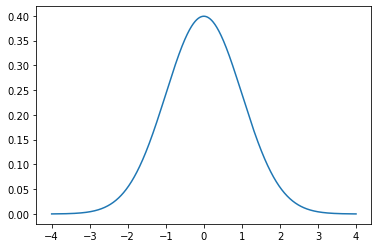

In [19]:
x = np.linspace(-4, 4, 1000)
 
plt.plot(x,norm.pdf(x, loc=0, scale=1))


In [11]:
 norm.pdf(x, mean_val, np.std(norm_data))

array([5.58974764e-05, 6.01840902e-05, 6.47794224e-05, 6.97040985e-05,
       7.49799990e-05, 8.06303265e-05, 8.66796759e-05, 9.31541080e-05,
       1.00081226e-04, 1.07490255e-04, 1.15412127e-04, 1.23879564e-04,
       1.32927171e-04, 1.42591530e-04, 1.52911296e-04, 1.63927298e-04,
       1.75682646e-04, 1.88222839e-04, 2.01595879e-04, 2.15852385e-04,
       2.31045718e-04, 2.47232107e-04, 2.64470776e-04, 2.82824078e-04,
       3.02357637e-04, 3.23140489e-04, 3.45245229e-04, 3.68748164e-04,
       3.93729467e-04, 4.20273342e-04, 4.48468187e-04, 4.78406763e-04,
       5.10186371e-04, 5.43909028e-04, 5.79681651e-04, 6.17616248e-04,
       6.57830105e-04, 7.00445982e-04, 7.45592318e-04, 7.93403429e-04,
       8.44019721e-04, 8.97587896e-04, 9.54261172e-04, 1.01419950e-03,
       1.07756978e-03, 1.14454609e-03, 1.21530991e-03, 1.29005037e-03,
       1.36896444e-03, 1.45225720e-03, 1.54014207e-03, 1.63284102e-03,
       1.73058482e-03, 1.83361331e-03, 1.94217557e-03, 2.05653021e-03,
      

In [14]:
x = np.linspace(-4, 4, 10)
y = norm.pdf(x, 0, 1)
print(y)

[1.33830226e-04 3.15601632e-03 3.37736510e-02 1.64010075e-01
 3.61423830e-01 3.61423830e-01 1.64010075e-01 3.37736510e-02
 3.15601632e-03 1.33830226e-04]


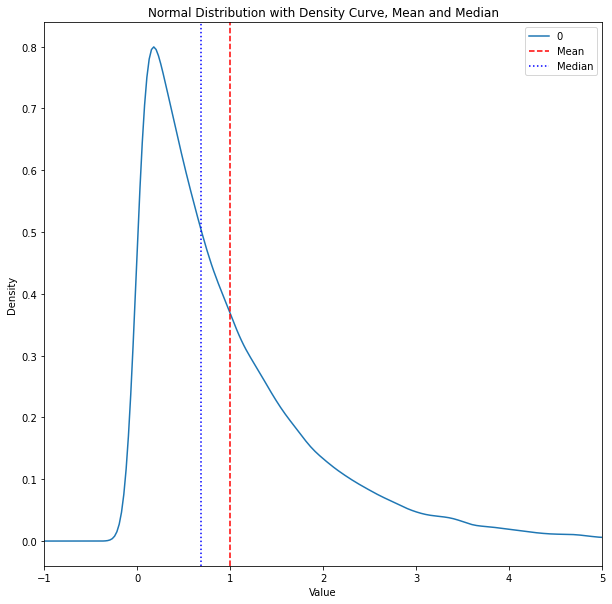

In [28]:
# Generate 10000 exponentially distributed numbers using np.random.exponential(size=100000) 
# and plot the density curve along with the median and mean.

import pandas as pd
import numpy as np

skewed_data = pd.DataFrame(np.random.exponential(size=100000))

mean_val = skewed_data.mean().iloc[0]
median_val = skewed_data.median().iloc[0]

skewed_data.plot(kind="density",figsize=(10,10),xlim=(-1,5))

plt.axvline(mean_val, linestyle='--', color='red', label='Mean')
plt.axvline(median_val, linestyle=':', color='blue', label='Median')

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Exponential Distribution with Density Curve, Mean and Median")
plt.legend()
plt.show()

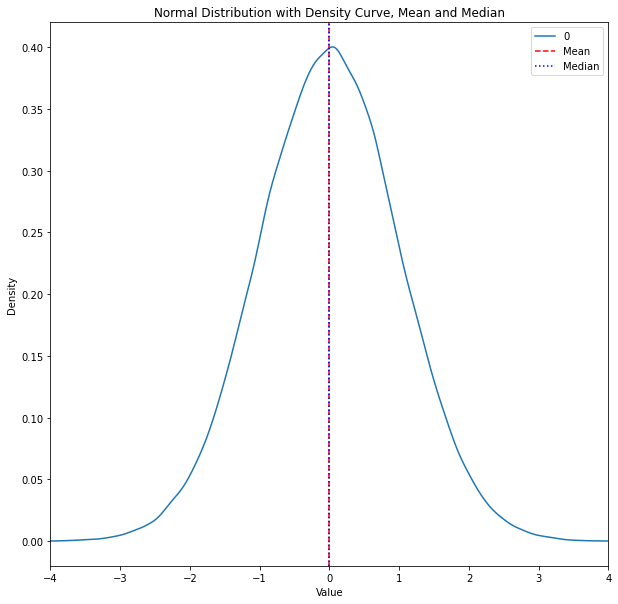

In [36]:
# Generate 10000 exponentially distributed numbers using np.random.exponential(size=100000) 
# and plot the density curve along with the median and mean.

import pandas as pd
import numpy as np

norm_data = pd.DataFrame(np.random.normal(size=100000))

mean_val = norm_data.mean().iloc[0]
median_val = norm_data.median().iloc[0]

norm_data.plot(kind="density",figsize=(10,10),xlim=(-4,4))

plt.axvline(mean_val, linestyle='--', color='red', label='Mean')
plt.axvline(median_val, linestyle=':', color='blue', label='Median')

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Normal Distribution with Density Curve, Mean and Median")
plt.legend()
plt.show()